## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [ ]:
data.shape

(344, 11)

In [ ]:
data.isna().sum()

,0
Species,0
Island,0
Clutch Completion,0
Date Egg,0
Culmen Length (mm),2
Culmen Depth (mm),2
Flipper Length (mm),2
Body Mass (g),2
Sex,10
Delta 15 N (o/oo),14


In [ ]:
data = data.dropna()

In [ ]:
data.shape

(325, 11)

Пропуски в данных были, удалили их при помощи метода dropna()

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 325 entries, 0 to 343
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Species              325 non-null    object 
 1   Island               325 non-null    object 
 2   Clutch Completion    325 non-null    object 
 3   Date Egg             325 non-null    int64  
 4   Culmen Length (mm)   325 non-null    float64
 5   Culmen Depth (mm)    325 non-null    float64
 6   Flipper Length (mm)  325 non-null    float64
 7   Body Mass (g)        325 non-null    float64
 8   Sex                  325 non-null    object 
 9   Delta 15 N (o/oo)    325 non-null    float64
 10  Delta 13 C (o/oo)    325 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 30.5+ KB


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

data = data.loc[data['Sex'].isin(['MALE', 'FEMALE'])] #удалили строку, в которой в столбце 'Sex' встречается '.'
data['Sex_encoded'] = data['Sex'].apply(lambda x: 1 if x == 'FEMALE' else 0)
data['Clutch_Completion_encoded'] = data['Clutch Completion'].apply(lambda x: 1 if x == 'Yes' else 0)

<ipython-input-69-d05223521e7f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Sex_encoded'] = data['Sex'].apply(lambda x: 1 if x == 'FEMALE' else 0)
<ipython-input-69-d05223521e7f>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Clutch_Completion_encoded'] = data['Clutch Completion'].apply(lambda x: 1 if x == 'Yes' else 0)


In [ ]:
island_encoded = pd.get_dummies(data['Island'])
data = pd.concat([data, island_encoded], axis=1)
data = data.drop(data['Island'], axis=1)

In [ ]:
encoder = OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']])
data['Species_encoded'] = encoder.fit_transform(data[['Species']])
X = data.drop(['Species', 'Species_encoded'], axis=1)
y = data['Species_encoded']

In [ ]:
data = data.drop(['Sex', 'Clutch Completion', 'Species'], axis=1)

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Аргумент stratify сохраняет распределение классов в целевой переменной y в тренировочной и в тестовой выборках. В случае, если классы несбалансированы (например, один класс составляет 90% данных, а другой 10%), тестовая выборка может не содержать достаточного количества примеров минорного класса, что приведет к некоректной оценке модели

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle

X = data[['Flipper Length (mm)', 'Body Mass (g)']]
y = data['Species_encoded']

X = X.dropna()
y = y.loc[X.index]
y = y.astype(np.int_)
np.random.seed(42)
X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf1 = KNeighborsClassifier(n_neighbors=1)
clf3 = KNeighborsClassifier(n_neighbors=3)
clf5 = KNeighborsClassifier(n_neighbors=5)
clf10 = KNeighborsClassifier(n_neighbors=10)
clf15 = KNeighborsClassifier(n_neighbors=15)
clf25 = KNeighborsClassifier(n_neighbors=25)

clf1.fit(X_train_scaled, y_train)
y_predicted1 = clf1.predict(X_test_scaled)

clf3.fit(X_train_scaled, y_train)
y_predicted3 = clf3.predict(X_test_scaled)

clf5.fit(X_train_scaled, y_train)
y_predicted5 = clf5.predict(X_test_scaled)

clf10.fit(X_train_scaled, y_train)
y_predicted10 = clf10.predict(X_test_scaled)

clf15.fit(X_train_scaled, y_train)
y_predicted15 = clf15.predict(X_test_scaled)

clf25.fit(X_train_scaled, y_train)
y_predicted25 = clf25.predict(X_test_scaled)

print("Доля правильных ответов при 1 соседе: ", np.mean(y_test == y_predicted1))
print("Доля правильных ответов при 3 соседях: ", np.mean(y_test == y_predicted3))
print("Доля правильных ответов при 5 соседях: ", np.mean(y_test == y_predicted5))
print("Доля правильных ответов при 10 соседях: ", np.mean(y_test == y_predicted10))
print("Доля правильных ответов при 15 соседях: ", np.mean(y_test == y_predicted15))
print("Доля правильных ответов при 25 соседях: ", np.mean(y_test == y_predicted25))

Доля правильных ответов при 1 соседе:  0.7551020408163265
Доля правильных ответов при 3 соседях:  0.826530612244898
Доля правильных ответов при 5 соседях:  0.8061224489795918
Доля правильных ответов при 10 соседях:  0.8367346938775511
Доля правильных ответов при 15 соседях:  0.8367346938775511
Доля правильных ответов при 25 соседях:  0.8163265306122449


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [ ]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [ ]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

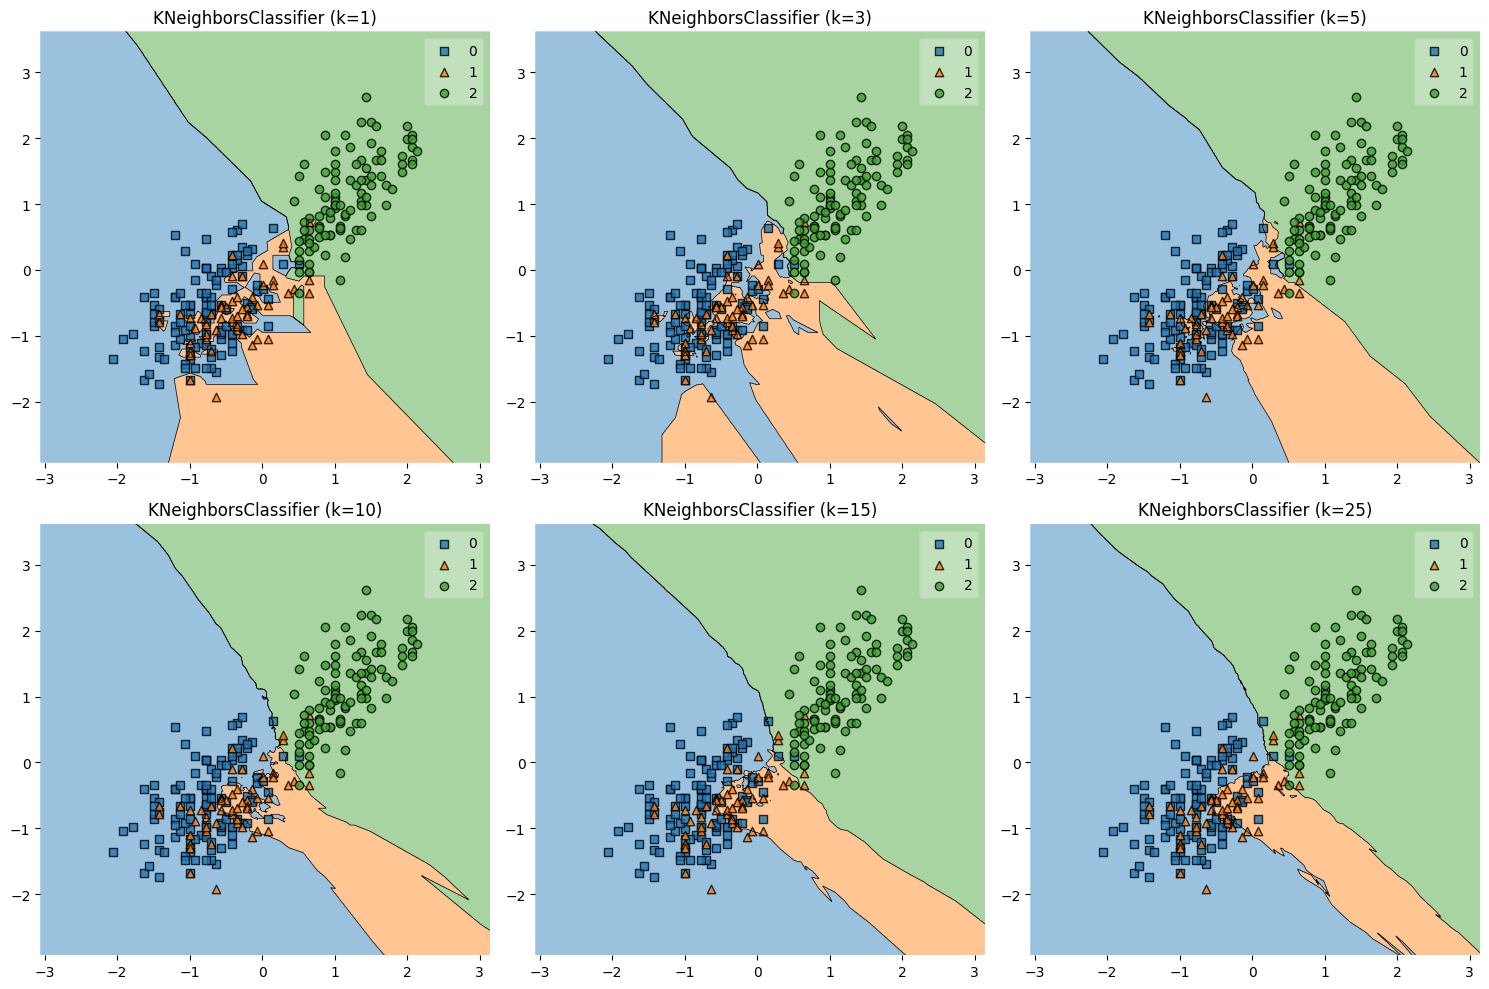

In [ ]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.

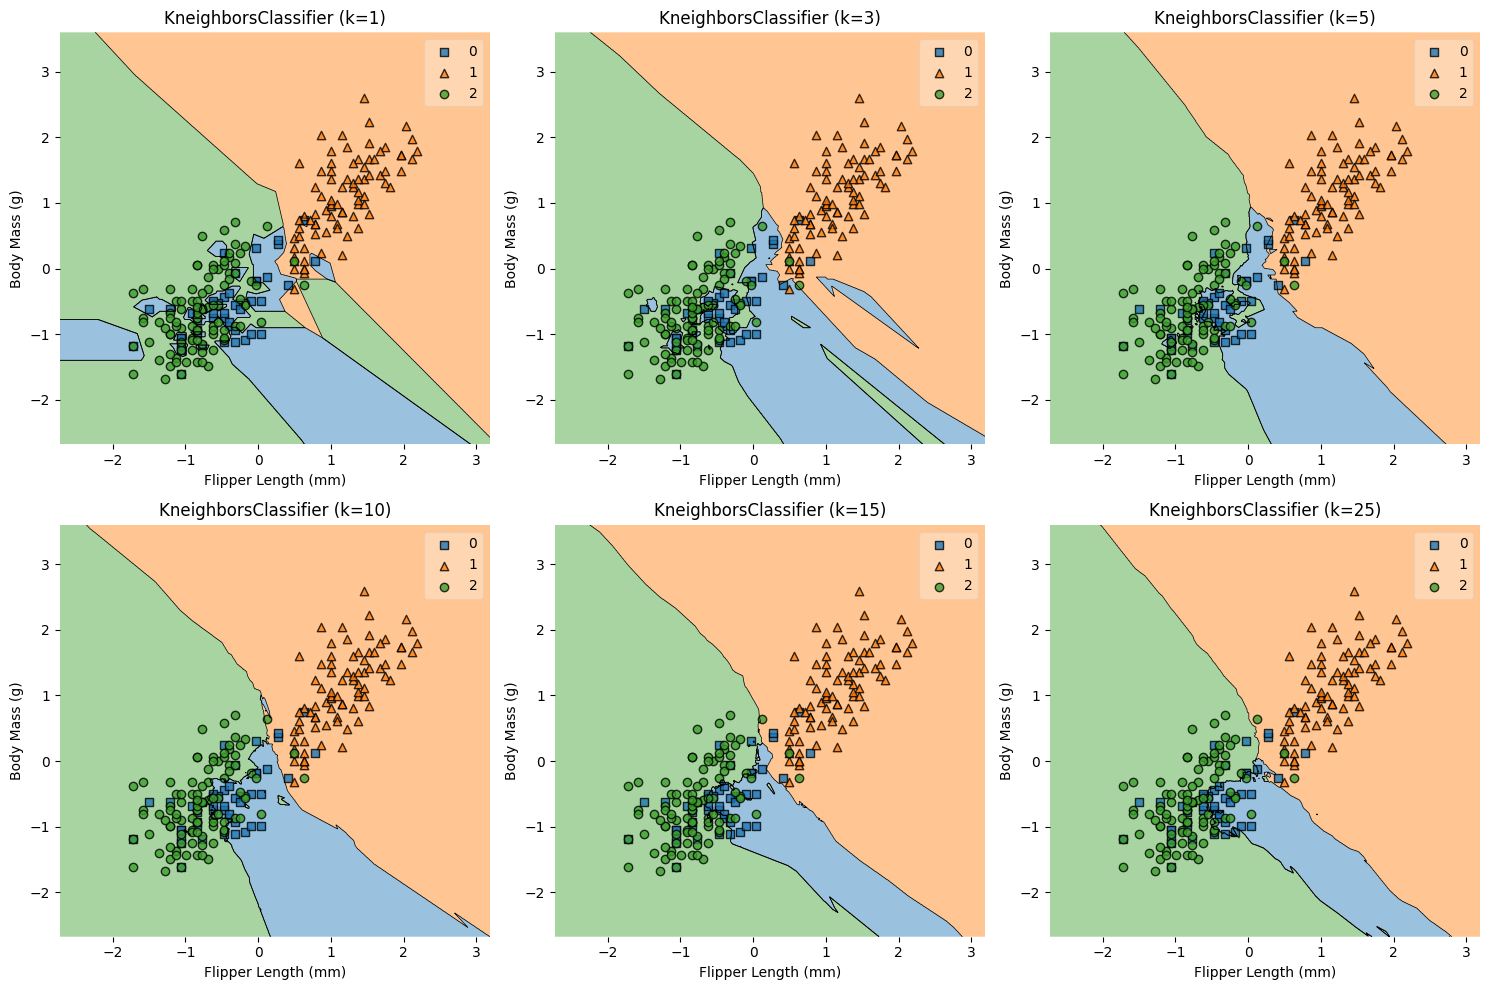

In [ ]:
import matplotlib.gridspec as gridspec
import itertools
from mlxtend.plotting import plot_decision_regions

classifiers = [clf1, clf3, clf5, clf10, clf15, clf25]

for clf in classifiers:
    clf.fit(X_train_scaled, y_train)

gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(15, 10))

titles = ['KneighborsClassifier (k=1)', 'KneighborsClassifier (k=3)', 'KneighborsClassifier (k=5)', 'KneighborsClassifier (k=10)', 'KneighborsClassifier (k=15)', 'KneighborsClassifier (k=25)']

for clf, title, grd in zip(classifiers, titles, itertools.product([0, 1], [0, 1, 2])):
    ax = plt.subplot(gs[grd[0], grd[1]])
    plot_decision_regions(X_train_scaled, y_train.values, clf=clf, legend=1)
    plt.title(title)
    plt.xlabel('Flipper Length (mm)')
    plt.ylabel('Body Mass (g)')

plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

Для обучения классификатора оптимальным будет использовать 10 или 15 соседей, так как доля правильных ответов прибоизительна равна 0.864. После визуализации видно, что на их графиках границы наиболее гладкие, можно предположить, что границы между классами соответствуют реальной структуре данных.

Что касается переобучения, то на графике с 1 соседом решающая поверхность очень сложная, с множеством мелких "островков", а границы между классами очень изрезанные, что не соответствует реальной структуре данных. Можно сделать вывод, что модель слишком сильно подстраивается под тренировочные данные, включая шум и выбросы

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

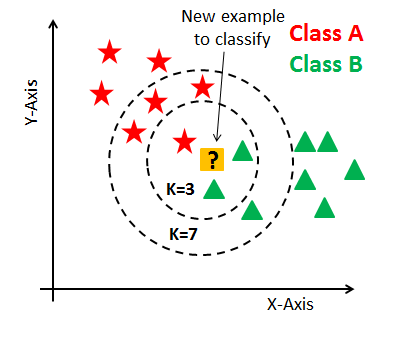

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k: int):
        self.k = k

    def fit(self, X, y):

        self.X_train = X
        self.y_train = y

    def predict(self, X):

        predictions = [self._predict(x) for x in X]
        return predictions

    def _predict(self, x):

        distances = [self.count_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)

        return most_common[0][0]

    def count_distance(self, x, y):

        return np.linalg.norm(x - y)
        pass

In [ ]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1, 0]

In [ ]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

best_k = 3
best_score = 0

param_grid = {'n_neighbors': list(range(1, 20))}
knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['n_neighbors']
best_score = grid_search.best_score_

print(f"Лучшее k: {best_k} с точностью {best_score} на кросс-валидации")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {test_accuracy}")

Лучшее k: 18 с точностью 0.7032850241545894 на кросс-валидации
Точность на тестовой выборке: 0.7755102040816326


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [ ]:
df = pd.read_csv('diamonds.csv')
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


Пропусков в данных нет

Что касается бессмысленных столбцов, то, изучив информацию о признаках на kaggle, по моему мнению, все данные важны

**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [ ]:
corr_mat = df.corr(numeric_only=True)
corr_mat

,Unnamed: 0,carat,depth,table,price,x,y,z
Unnamed: 0,1.000000,-0.377983,-0.034800,-0.100830,-0.306873,-0.405440,-0.395843,-0.399208
carat,-0.377983,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,-0.034800,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,-0.100830,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,-0.306873,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,-0.405440,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,-0.395843,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,-0.399208,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


Наибольшую корреляцию с целевой переменной price имеет вес бриллианта carat (0.921591), а также длина x, ширина y и глубина z (0.884435, 0.865421 и 0.861249, соответственно)

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [ ]:
df_dum = pd.get_dummies(df, drop_first=True)
df_dum

,Unnamed: 0,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,1,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,...,False,False,False,False,False,True,False,False,False,False
1,2,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,...,False,False,False,False,True,False,False,False,False,False
2,3,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,...,False,False,False,False,False,False,True,False,False,False
3,4,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,...,False,True,False,False,False,False,False,True,False,False
4,5,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,True,...,False,False,False,False,True,False,False,False,False,False
53936,53937,0.72,63.1,55.0,2757,5.69,5.75,3.61,True,False,...,False,False,False,False,True,False,False,False,False,False
53937,53938,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,53939,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,...,True,False,False,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [ ]:
X = df_dum.drop(['price'], axis=1)
y = df_dum['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

После стандартизации все признаки будут иметь одинаковый масштаб, что особенно полезно для алгоритмов машинного обучения, таких как линейная регрессия, которые чувствительны к масштабу данных. Это позволяет сравнивать влияние разных признаков на целевую переменную, так как все признаки теперь находятся в одном масштабе. После стандартизации коэффициенты больше не могут интерпретироваться как "при увеличении  X1  на 1,  y  увеличивается на  w1", потому что признаки теперь измеряются в стандартных отклонениях от среднего, а не в исходных единицах измерения.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr = LinearRegression()

model = lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
pred_test = lr.predict(X_test)

print(f'Train: {mean_squared_error(y_train, pred_train)}')
print(f'Test: {mean_squared_error(y_test, pred_test)}')

Train: 1285303.3625795962
Test: 1238015.3387700708


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [ ]:
coefficients = model.coef_
feature_names = X_train.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
coef_df

,Feature,Coefficient
0,Unnamed: 0,0.005138
1,carat,11156.840053
2,depth,-58.939998
3,table,-26.144171
4,x,-927.052320
5,y,-2.989372
6,z,-49.090793
7,cut_Good,607.826123
8,cut_Ideal,851.622256
9,cut_Premium,786.252923


Вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных: carat, clarity_IF, clarity_VVS1, clarity_VVS2

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [ ]:
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=10)
lasso_model.fit(X_train_scaled, y_train)

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled, y_train)

coef_df['Lasso_Coefficient'] = lasso_model.coef_
coef_df['Ridge_Coefficient'] = ridge_model.coef_

coef_df

,Feature,Coefficient,Lasso_Coefficient,Ridge_Coefficient
0,Unnamed: 0,0.005138,78.988037,80.804585
1,carat,11156.840053,4799.184693,5266.551610
2,depth,-58.939998,-90.691889,-82.412563
3,table,-26.144171,-69.861695,-58.439922
4,x,-927.052320,-589.452277,-997.633295
5,y,-2.989372,-0.000000,-5.865791
6,z,-49.090793,-28.819624,-38.000175
7,cut_Good,607.826123,49.661436,174.742177
8,cut_Ideal,851.622256,209.516171,418.121837
9,cut_Premium,786.252923,155.060628,343.921362


Проблема мультиколлинеарности в изначальной линейной регрессии проявлялась сильно, о чем свидетельствуют большие значения коэффициентов для некоторых признаков, некоторые из которых после преобразований уменьшились в 4-5 и более раз

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

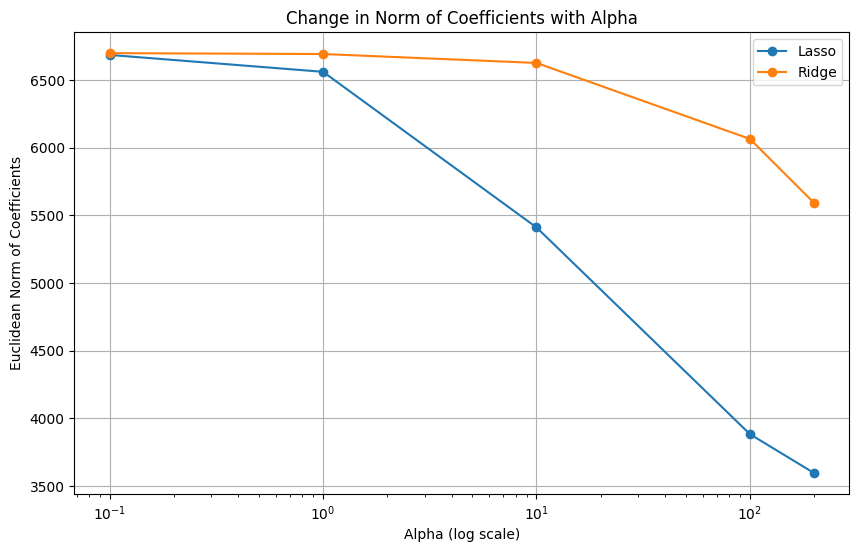

In [ ]:
alphas = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []
for alpha in alphas:
    lasso_model = Lasso(alpha=alpha)
    lasso_model.fit(X_train_scaled, y_train)
    lasso_norms.append(np.linalg.norm(lasso_model.coef_))

    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train_scaled, y_train)
    ridge_norms.append(np.linalg.norm(ridge_model.coef_))

plt.figure(figsize=(10, 6))
plt.plot(alphas, lasso_norms, label='Lasso', marker='o')
plt.plot(alphas, ridge_norms, label='Ridge', marker='o')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Euclidean Norm of Coefficients')
plt.title('Change in Norm of Coefficients with Alpha')
plt.legend()
plt.grid(True)
plt.show()

Из графика видно, что метод Lasso сильнее снижает норму коэффициентов, чем Ridge

Именно Lasso-регрессию часто используют для отбора признаков, так как она имеет свойство обнулять коэффициенты менее значимых признаков. Это делает её полезной для отбора признаков, так как она автоматически исключает неважные переменные из модели

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [ ]:
from sklearn.linear_model import LassoCV
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)
mse_path = lasso_cv.mse_path_
mean_mse = mse_path.mean(axis=1)

mse_df = pd.DataFrame({'Alpha': lasso_cv.alphas_, 'Mean MSE': mean_mse})
mse_df

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 874633893.9050751, tolerance: 48476565.465277866
  model = cd_fast.enet_coordinate_descent_gram(


,Alpha,Mean MSE
0,200.0,2.178987e+06
1,100.0,1.804951e+06
2,10.0,1.348723e+06
3,1.0,1.288881e+06
4,0.1,1.292135e+06


In [ ]:
optimal_alpha = lasso_cv.alpha_
print(f'Оптимальное значение alpha: {optimal_alpha}')

Оптимальное значение alpha: 1.0


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [ ]:
final_lasso = Lasso(alpha=optimal_alpha)
final_lasso.fit(X_train_scaled, y_train)

final_coef_df = pd.DataFrame({'Feature': X_train_scaled.columns, 'Coefficient': final_lasso.coef_})
final_coef_df

,Feature,Coefficient
0,Unnamed: 0,79.873291
1,carat,5254.772766
2,depth,-84.779299
3,table,-59.353750
4,x,-997.815199
5,y,-0.000000
6,z,-34.623510
7,cut_Good,161.744653
8,cut_Ideal,396.415347
9,cut_Premium,324.301541


Неинформативные признаки (коэффициенты близки к нулю или равны нулю):

y(-0.000000) был полностью исключен из модели. Это может быть связано с тем, что его влияние на цену бриллианта либо минимально, либо уже учтено через другие признаки (например, x или carat).

Наиболее информативные признаки:

carat (5254.772766) является самым важным признаком для предсказания цены. Это логично, так как всегда чем больше вес бриллианта, тем выше цена

x (-997.815199): является важным признаком, хотя его влияние отрицательное. Это может быть связано с тем, что при увеличении размера по оси X (при фиксированном весе) бриллиант может казаться менее качественным, что снижает его цену

Категориальные признаки (cut, color, clarity):

cut:

Коэффициенты для категорий cut положительные, что указывает на то, что более высокая категория огранки увеличивает цену

cut_Ideal: 396.415347

cut_Premium: 324.301541

cut_Very Good: 298.710907

Это может объясняться с тем, что чем лучше огранка, тем выше цена.

color:

Коэффициенты для категорий color отрицательные, что указывает на то, что более низкие категории цвета, например, J, снижают цену. Например:

color_J: -524.332552

color_I: -436.586619

color_H: -352.761416

Чем меньше цветовых дефектов (ближе к D), тем выше цена

clarity:

Коэффициенты для категорий clarity положительные, что указывает на то, что более высокая чистота увеличивает цену

clarity_VS2: 1746.247598

clarity_VS1: 1609.242825

clarity_SI1: 1539.996191

Это ожидаемо, чем меньше включений и дефектов, тем выше цена

depth и table: -84.779299 и -59.353750 соответственно

Эти признаки имеют небольшое влияние на цену, но их коэффициенты не были обнулены. Это может указывать на то, что они имеют слабое, но статистически значимое влияние на цену

z: -34.623510

Размер по оси Z также имеет небольшое влияние на цену, но его коэффициент не был обнулен


Наиболее информативные признаки: carat, x, а также категориальные признаки (cut, color, clarity).

Неинформативные признаки: y был исключен из модели.

Слабые, но значимые признаки: depth, table, и z имеют небольшое влияние на цену.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [ ]:
y_pred_lasso = lasso_model.predict(X_test)
y_pred_linear = model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
mse_linear = mean_squared_error(y_test, y_pred_linear)

print(f"MSE Lasso: {mse_lasso}")
print(f"MSE Linear Regression: {mse_linear}")

MSE Lasso: 14323551.257431034
MSE Linear Regression: 1238015.3387700708


Обычная линейная регрессия показала значительно меньшую ошибку по сравнению с Lasso-регрессией. Это означает, что обычная линейная регрессия лучше подходит для предсказаний. Это может быть связано с тем, что Lasso-регрессия полезна, когда в данных много незначимых или избыточных признаков, которые она может обнулить с помощью L1-регуляризации. В наших данных практически нет избыточных или незначимых признаков. Более того, Lasso-регрессия хорошо справляется с мультиколлинеарностью. Если в ваших данных мультиколлинеарность отсутствует или слабо выражена, Lasso может не дать преимущества.

Но и возможно, что мы ошиблись и параметр регуляризации (α) в Lasso-регрессии был выбран слишком большим, что привело к излишнему упрощению модели и потере важной информации:)